In [1]:
import pandas as pd
import ast
csv = pd.read_csv("csv/Merged10sec.csv")



In [ ]:
import pandas as pd

# 1. Definir las rutas de tus 3 datasets (ajusta los nombres de archivo)
datasets = {
    "Ventana 1": "csv/Merged1sec.csv",
    "Ventana 2": "csv/Merged5s.csv",
    "Ventana 3": "csv/Merged10sec.csv"
}

# Lista para guardar los resultados de cada dataset
resumen_lista = []

for nombre_ventana, archivo in datasets.items():
    # Cargar solo las columnas necesarias para ahorrar memoria (útil en archivos grandes)
    df = pd.read_csv(archivo, usecols=['label1', 'label2'])
    
    # Contar para label1
    counts_l1 = df['label1'].value_counts().rename(f'label1_{nombre_ventana}')
    
    # Contar para label2
    counts_l2 = df['label2'].value_counts().rename(f'label2_{nombre_ventana}')
    
    # Combinar ambos conteos en un pequeño DataFrame temporal
    # Usamos outer join por si una etiqueta aparece en un label pero no en el otro
    resumen_ventana = pd.concat([counts_l1, counts_l2], axis=1)
    resumen_lista.append(resumen_ventana)

# 2. Unir todos los resultados en una tabla maestra
# El índice serán los nombres de los ataques/etiquetas
tabla_final = pd.concat(resumen_lista, axis=1).fillna(0).astype(int)

# 3. Opcional: Añadir una columna de "Total" para ver el volumen general
tabla_final['Total_Global'] = tabla_final.sum(axis=1)

# Ordenar por la que tenga más muestras totales
tabla_final = tabla_final.sort_values(by='Total_Global', ascending=False)

print("### Comparativa de etiquetas por Ventana de Tiempo ###")
print(tabla_final)

# Guardar a CSV para meterlo en el Excel del TFG
#tabla_final.to_csv("tabla_resumen_etiquetas.csv")

### Comparativa de etiquetas por Ventana de Tiempo ###
            label1_Ventana 1  label2_Ventana 1  label1_Ventana 2  \
benign                136800            136800             27360   
attack                 90391                 0             17695   
recon                      0             33648                 0   
dos                        0             18420                 0   
ddos                       0             18056                 0   
mitm                       0              8062                 0   
malware                    0              7541                 0   
web                        0              2796                 0   
bruteforce                 0              1868                 0   

            label2_Ventana 2  label1_Ventana 3  label2_Ventana 3  Total_Global  
benign                 27360             13680             13680        355680  
attack                     0             16350                 0        124436  
recon                

In [2]:
pd.set_option('display.max_rows', None)
print(len(csv['label3'].value_counts(dropna=False)))

61


In [4]:
# Carga tu csv
df = pd.read_csv("csv/label1_Merged_DF.csv")

# Encuentra qué columnas tienen strings
for col in df.columns:
    try:
        df[col].astype(float)
    except ValueError:
        print(f"⚠️ La columna '{col}' contiene texto. Ejemplo: {df[col].iloc[0]}")

In [6]:
import joblib
from sklearn.preprocessing import StandardScaler, LabelEncoder
le8 = joblib.load('csv/le/le_label2_test.csv')
le60 = joblib.load('csv/le/le_label3_test.csv')
lebin = joblib.load('csv/le/le_label1_test.csv')

print(le8.classes_)

['benign' 'bruteforce' 'ddos' 'dos' 'malware' 'mitm' 'recon' 'web']


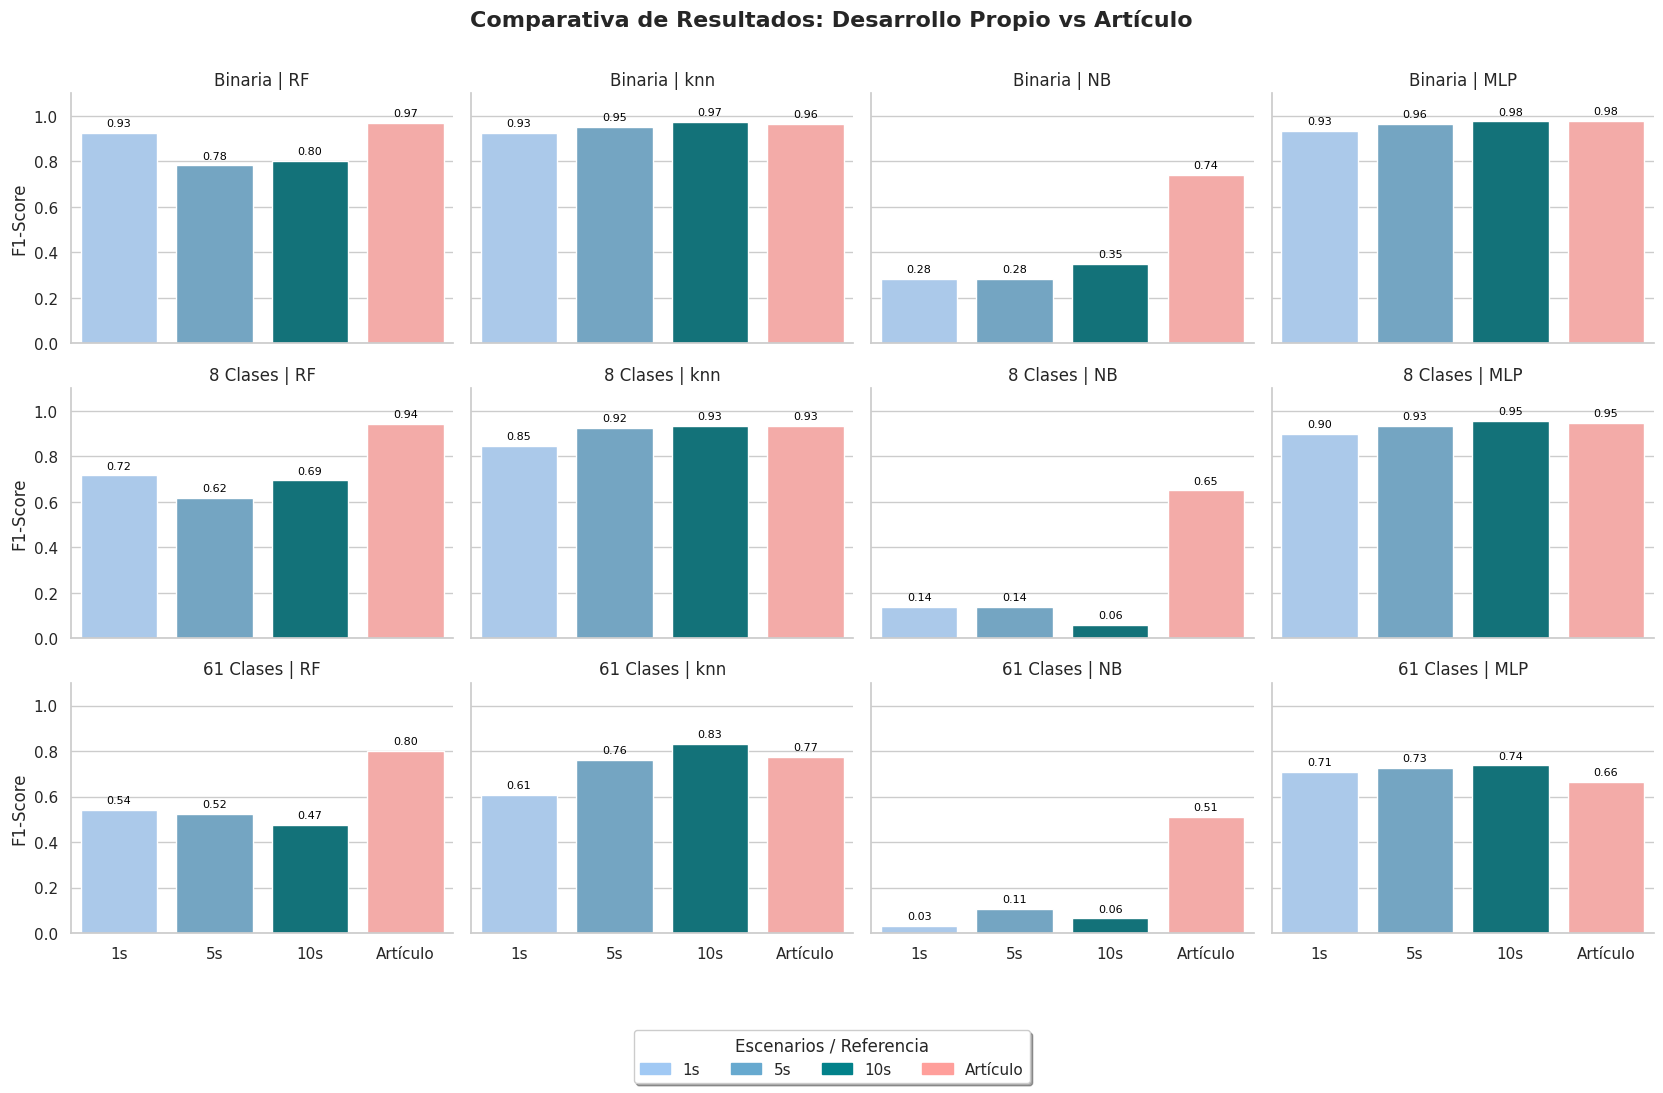

In [6]:
# --- SECCIÓN PARA RELLENAR ---
# Sustituye el número después de 'f1_score': por tus resultados reales

resultados_propios = [
    # --- CLASIFICACIÓN BINARIA ---
    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': '1s', 'f1_score': 0.925217},
    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': '5s', 'f1_score': 0.782587},
    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': '10s', 'f1_score': 0.800781},
    
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': '1s', 'f1_score': 0.926182},
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': '5s', 'f1_score': 0.951126},
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': '10s', 'f1_score': 0.971616},
    
    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': '1s', 'f1_score': 0.284954},
    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': '5s', 'f1_score': 0.284898},
    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': '10s', 'f1_score': 0.348873},
    
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': '1s', 'f1_score': 0.932579},
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': '5s', 'f1_score': 0.962932},
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': '10s', 'f1_score': 0.975778},

    # --- CLASIFICACIÓN 8 CLASES ---
    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': '1s', 'f1_score': 0.7156450},
    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': '5s', 'f1_score': 0.617998},
    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': '10s', 'f1_score': 0.693592},
    
    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': '1s', 'f1_score': 0.845358},
    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': '5s', 'f1_score': 0.923541},
    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': '10s', 'f1_score': 0.934081},
    
    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': '1s', 'f1_score': 0.137521},
    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': '5s', 'f1_score': 0.137610},
    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': '10s', 'f1_score': 0.058976},
    
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': '1s', 'f1_score': 0.897642},
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': '5s', 'f1_score': 0.931723},
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': '10s', 'f1_score': 0.953543},

    # --- CLASIFICACIÓN 61 CLASES ---
    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': '1s', 'f1_score': 0.540905},
    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': '5s', 'f1_score': 0.523873},
    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': '10s', 'f1_score': 0.474908},
    
    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': '1s', 'f1_score': 0.608520},
    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': '5s', 'f1_score': 0.759398},
    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': '10s', 'f1_score': 0.831171},
    
    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': '1s', 'f1_score': 0.032254},
    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': '5s', 'f1_score': 0.106836},
    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': '10s', 'f1_score': 0.064375},
    
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': '1s', 'f1_score': 0.707176},
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': '5s', 'f1_score': 0.726306},
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': '10s', 'f1_score': 0.736874},
]

resultados_articulo = [
    # Binaria
    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': 'Artículo', 'f1_score': 0.9701},
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': 'Artículo', 'f1_score': 0.9637},
    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': 'Artículo', 'f1_score': 0.7422},
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': 'Artículo', 'f1_score': 0.9780},
    # 8 Clases
    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': 'Artículo', 'f1_score': 0.9429},
    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': 'Artículo', 'f1_score': 0.9325},
    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': 'Artículo', 'f1_score': 0.6496},
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': 'Artículo', 'f1_score': 0.9460},
    # 61 Clases
    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': 'Artículo', 'f1_score': 0.8007},
    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': 'Artículo', 'f1_score': 0.7730},
    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': 'Artículo', 'f1_score': 0.5100},
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': 'Artículo', 'f1_score': 0.6641},
]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combinamos tus datos en un DataFrame
df = pd.DataFrame(resultados_propios + resultados_articulo)

# Definimos el estilo y la paleta exacta
sns.set_theme(style="whitegrid")
palette = {"1s": "#a1c9f4", "5s": "#67a9cf", "10s": "#02818a", "Artículo": "#ff9f9b"}

# Usamos catplot en lugar de FacetGrid + map
# Esto gestiona automáticamente los ejes, las filas, las columnas y la LEYENDA
g = sns.catplot(
    data=df,
    kind="bar",
    x="Escenario",
    y="f1_score",
    hue="Escenario",
    col="Modelo",
    row="Clasificación",
    palette=palette,
    height=3.5,
    aspect=1.2,
    dodge=False,
    legend=False  # La crearemos manualmente para control total
)

# Ajustes estéticos de títulos y ejes
g.set_axis_labels("", "F1-Score")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set(ylim=(0, 1.1))

# Añadir etiquetas de valor sobre las barras (opcional, pero queda muy bien en TFG)
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        fontsize=8, color='black', 
                        xytext=(0, 7), 
                        textcoords='offset points')

# Configuración manual de la leyenda para que aparezca clara y fuera del gráfico
# Esto soluciona el problema de que no aparezca o salga mal
handles = [plt.Rectangle((0,0),1,1, color=palette[key]) for key in palette]
labels = palette.keys()
g.fig.legend(handles, labels, title="Escenarios / Referencia", 
             loc='lower center', bbox_to_anchor=(0.5, -0.05), 
             ncol=4, frameon=True, shadow=True)

# Título principal y ajuste de espacio
plt.subplots_adjust(top=0.9, bottom=0.1)
g.fig.suptitle('Comparativa de Resultados: Desarrollo Propio vs Artículo', 
               fontsize=16, fontweight='bold')

plt.savefig("pdfs/f1nobalanced.pdf", format="pdf")  
plt.show()

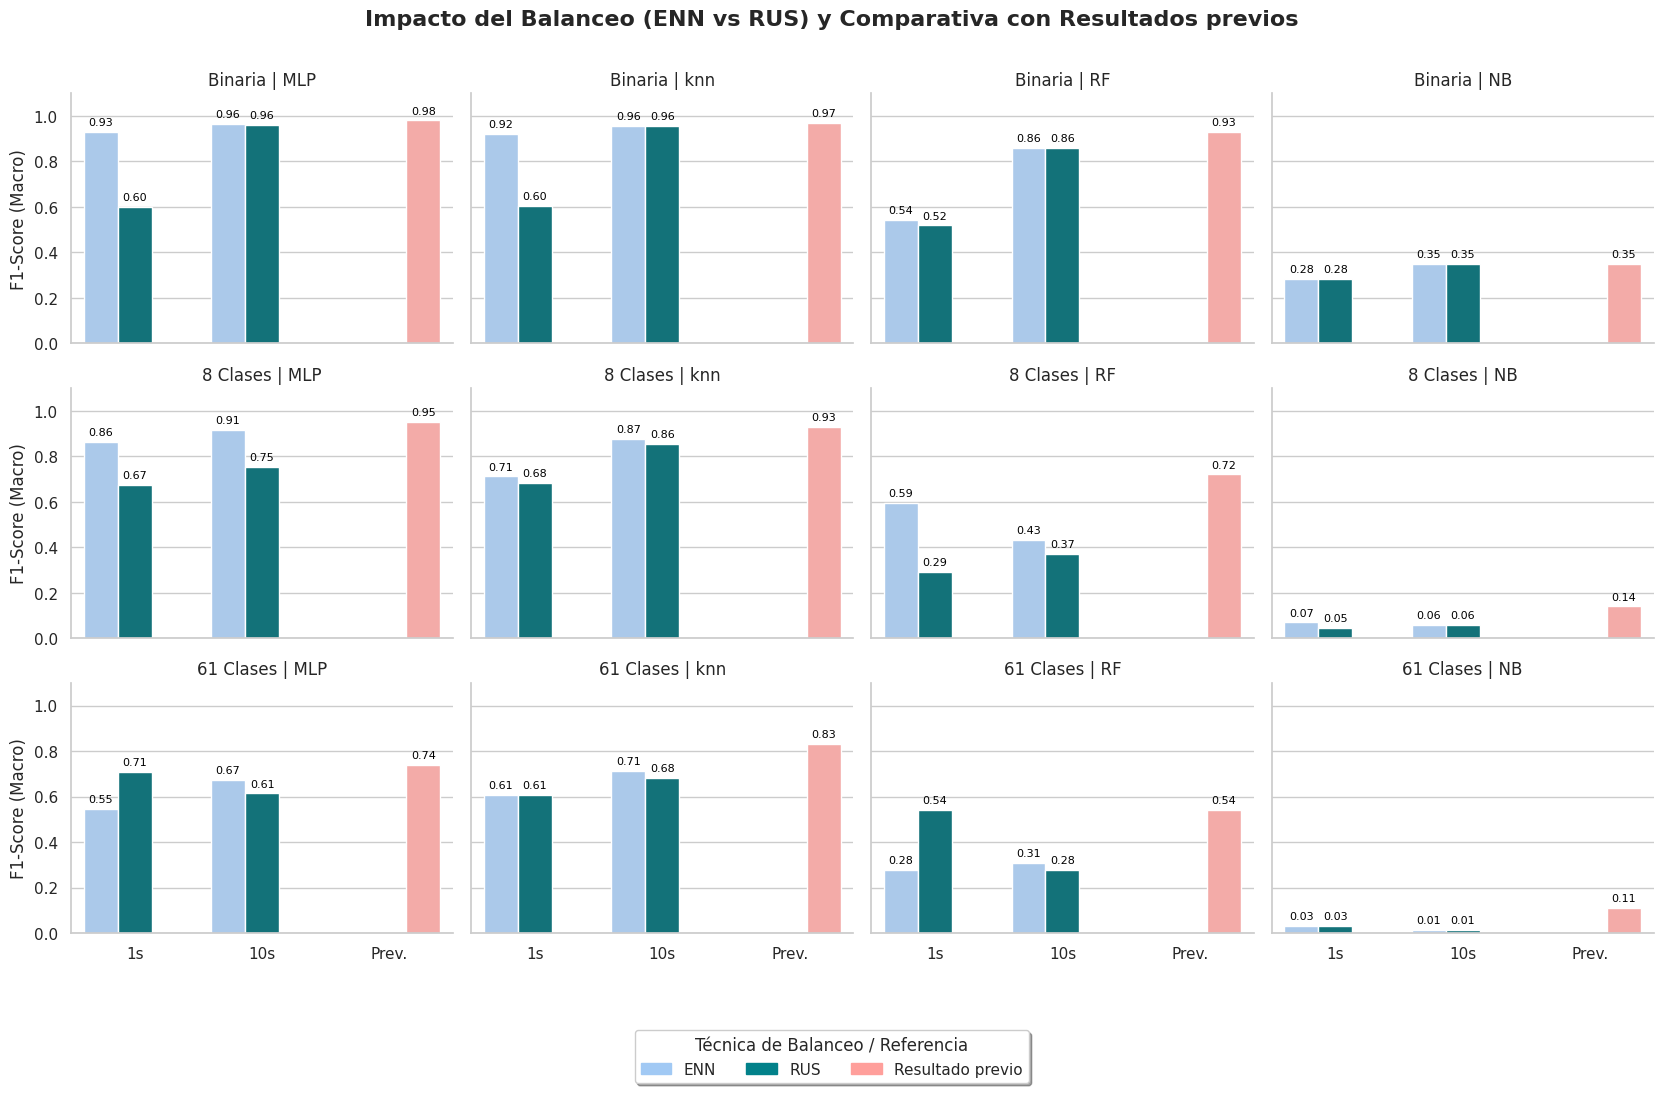

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- RELLENA TUS RESULTADOS AQUÍ ---
# He incluido los de RUS que ya conoces y puesto 0.0 en ENN para que los completes
resultados_propios = [
    # BINARIA
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.929347},
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.598108},
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.964647},
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.960660},
    
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.922324},
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.603104},
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.956499},
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.956499},

    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.543322},
    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.518349},
    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.860230},
    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.860230},

    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.284954},
    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.284954},
    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.348873},
    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.348873},

    # 8 CLASES
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.862288},
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.674836},
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.914341},
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.752922},

    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.711233},
    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.682296},
    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.874632},
    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.855093},

    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.593286},
    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.292214},
    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.432447},
    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.370873},

    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.069620},
    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.047213},
    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.058805},
    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.058883},

    # 61 CLASES
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.547303},
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.707176},
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.672256},
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.614059},

    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.606155},
    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.608520},
    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.714240},
    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.680877},

    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.277200},
    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.540905},
    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.310008},
    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.279226},

    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': '1s', 'Técnica': 'ENN', 'f1_score': 0.031313},
    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': '1s', 'Técnica': 'RUS', 'f1_score': 0.032254},
    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': '10s', 'Técnica': 'ENN', 'f1_score': 0.014328},
    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': '10s', 'Técnica': 'RUS', 'f1_score': 0.014588},
]

# --- DATOS ARTÍCULO (REFERENCIA FIJA) ---
# He puesto Escenario 'Art.' para que aparezca como una categoría separada en el eje X
resultados_articulo = [
    {'Clasificación': 'Binaria', 'Modelo': 'RF', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.93},
    {'Clasificación': 'Binaria', 'Modelo': 'knn', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.97},
    {'Clasificación': 'Binaria', 'Modelo': 'NB', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.35},
    {'Clasificación': 'Binaria', 'Modelo': 'MLP', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.98},
    {'Clasificación': '8 Clases', 'Modelo': 'RF', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.72},
    {'Clasificación': '8 Clases', 'Modelo': 'knn', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.93},
    {'Clasificación': '8 Clases', 'Modelo': 'NB', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.14},
    {'Clasificación': '8 Clases', 'Modelo': 'MLP', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.95},
    {'Clasificación': '61 Clases', 'Modelo': 'RF', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.54},
    {'Clasificación': '61 Clases', 'Modelo': 'knn', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.83},
    {'Clasificación': '61 Clases', 'Modelo': 'NB', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.11},
    {'Clasificación': '61 Clases', 'Modelo': 'MLP', 'Escenario': 'Prev.', 'Técnica': 'Resultado previo', 'f1_score': 0.74},
]

# Combinamos datos
df = pd.DataFrame(resultados_propios + resultados_articulo)

# Definimos estilo y paleta
# He usado dos tonos de azul para diferenciar tus pruebas y el rosa/rojo para el artículo
sns.set_theme(style="whitegrid")
palette = {"ENN": "#a1c9f4", "RUS": "#02818a", "Resultado previo": "#ff9f9b"}

# Creamos el catplot
# 'dodge=True' es vital para que ENN y RUS salgan una al lado de la otra
g = sns.catplot(
    data=df,
    kind="bar",
    x="Escenario",
    y="f1_score",
    hue="Técnica",
    col="Modelo",
    row="Clasificación",
    palette=palette,
    height=3.5,
    aspect=1.2,
    dodge=True, 
    legend=False,
    col_order=['MLP', 'knn', 'RF', 'NB']
)

# Ajustes de títulos y ejes
g.set_axis_labels("", "F1-Score (Macro)")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.set(ylim=(0, 1.1))

# Añadir etiquetas de valor
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.2f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        fontsize=8, color='black', 
                        xytext=(0, 7), 
                        textcoords='offset points')

# Leyenda manual idéntica a la tuya
handles = [plt.Rectangle((0,0),1,1, color=palette[key]) for key in palette]
labels = palette.keys()
g.fig.legend(handles, labels, title="Técnica de Balanceo / Referencia", 
             loc='lower center', bbox_to_anchor=(0.5, -0.05), 
             ncol=3, frameon=True, shadow=True)

# Título principal
plt.subplots_adjust(top=0.9, bottom=0.1)
g.fig.suptitle('Impacto del Balanceo (ENN vs RUS) y Comparativa con Resultados previos', 
               fontsize=16, fontweight='bold')
plt.savefig("pdfs/f1balanced.pdf", format="pdf")  
plt.show()

Calculando t-SNE para 5000 muestras... (Técnica: EditedNearestNeighbours)


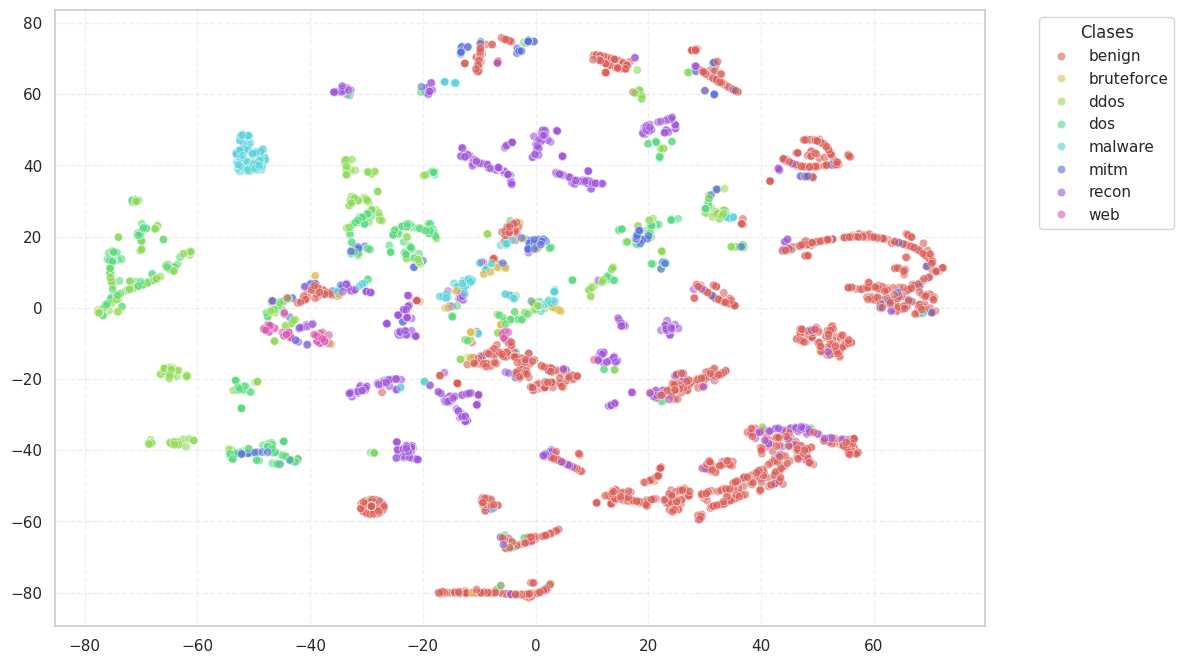

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('csv/label2_10s.csv')
# 1. Preparación y Split (Asegúrate de tener df definido)
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. SELECCIÓN DE ESTRATEGIA (Descomenta la que quieras usar)
# Opción A: ENN Dirigido (Solo limpia la clase Benigna - ID 0)
#resampler = EditedNearestNeighbours(sampling_strategy=[0], n_neighbors=3, kind_sel='all')

# Opción B: RUS (Coméntala si usas ENN)
resampler = RandomUnderSampler(sampling_strategy={0: 9000}, random_state=42)

# 3. Aplicar Resampling y Escalado
X_res, y_res = resampler.fit_resample(X_train, y_train)

scaler = StandardScaler()
# Escalamos solo las X. Las y se quedan como etiquetas (labels) originales.
X_train_scaled = scaler.fit_transform(X_res) 

# 4. Muestreo para t-SNE (Para no colapsar la RAM)
n_samples_plot = 5000 
if len(y_res) > n_samples_plot:
    # Usamos random state para que el gráfico sea reproducible
    idx = np.random.choice(len(y_res), n_samples_plot, replace=False)
    X_viz = X_train_scaled[idx]
    # Manejo de Series de pandas o arrays de numpy para y
    y_viz = y_res.iloc[idx] if isinstance(y_res, pd.Series) else y_res[idx]
else:
    X_viz, y_viz = X_train_scaled, y_res

# 5. Ejecución de t-SNE
print(f"Calculando t-SNE para {len(y_viz)} muestras... (Técnica: {resampler.__class__.__name__})")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_viz) # Corregido: fit_transform

# 6. Plot
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], 
    hue=y_viz, 
    palette=sns.color_palette("hls", 8), 
    legend="full", 
    alpha=0.6,
    #edgecolor='none'
)
nombres_clases = ['benign', 'bruteforce', 'ddos', 'dos', 'malware', 'mitm', 'recon', 'web']
handles, labels = ax.get_legend_handles_labels()
#plt.title(f"Visualización t-SNE del Entrenamiento\n(Balanceo: {resampler.__class__.__name__})", fontsize=15)
plt.legend(handles, nombres_clases, title="Clases", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig('pdfs/tsnebalanceadoENN.pdf', format='pdf')
plt.show()


In [16]:
# 1. Contamos las muestras de cada conjunto
counts_train = pd.Series(y_res).value_counts().sort_index()
counts_test = pd.Series(y_test).value_counts().sort_index()

# 2. Creamos el DataFrame base
# Usamos un índice común para asegurar que todas las clases aparezcan
df_total = pd.DataFrame({
    'Train (Post-Resampling)': counts_train,
    'Test (Original)': counts_test
}).fillna(0).astype(int)

# 3. Añadimos nombres de categorías si estamos en el escenario de 8 clases
if len(df_total) == len(nombres_clases):
    df_total.index = nombres_clases
    df_total.index.name = 'Categoría'
else:
    df_total.index.name = 'ID Clase'

# 4. Calculamos el total por fila
df_total['Total Global'] = df_total['Train (Post-Resampling)'] + df_total['Test (Original)']

# 5. Visualización con estilo
print("Distribución Final de Muestras (Dataset Completo para Experimentos):")
display(df_total.style.bar(subset=['Total Global'], color='#a1c9f4')
                     .bar(subset=['Train (Post-Resampling)'], color='#5fba7d')
                     .bar(subset=['Test (Original)'], color='#ff9f9b')
                     .set_properties(**{'text-align': 'center'}))

# 6. Resumen de totales absolutos
print(f"\n--- Resumen de Volúmenes ---")
print(f"Total Muestras en Entrenamiento: {df_total['Train (Post-Resampling)'].sum()}")
print(f"Total Muestras en Test:          {df_total['Test (Original)'].sum()}")
print(f"TOTAL DATASET:                   {df_total['Total Global'].sum()}")

Distribución Final de Muestras (Dataset Completo para Experimentos):


,Train (Post-Resampling),Test (Original),Total Global
Categoría,,,
benign,101731,27361,129092
bruteforce,1494,374,1868
ddos,14445,3611,18056
dos,14736,3684,18420
malware,6033,1508,7541
mitm,6450,1612,8062
recon,26918,6730,33648
web,2237,559,2796



--- Resumen de Volúmenes ---
Total Muestras en Entrenamiento: 174044
Total Muestras en Test:          45439
TOTAL DATASET:                   219483


In [4]:
import pandas as pd
# Leer el dataset
df = pd.read_csv('csv/MergedBalanced.csv')

# Contar valores de label1 y label2
counts_label1 = df['label1'].value_counts()
counts_label2 = df['label2'].value_counts()
counts_label3 = df['label3'].value_counts()

# Mostrar resultados
print("=== Conteo de label1 ===")
print(counts_label1)
print(f"\nTotal de categorías en label1: {len(counts_label1)}")

print("\n=== Conteo de label2 ===")
print(counts_label2)
print(f"\nTotal de categorías en label2: {len(counts_label2)}")

print("\n=== Conteo de label3 ===")
print(counts_label3)
print(f"\nTotal de categorías en label3: {len(counts_label3)}")

=== Conteo de label1 ===
label1
attack    143631
benign     26628
Name: count, dtype: int64

Total de categorías en label1: 2

=== Conteo de label2 ===
label2
dos           26632
web           26628
malware       26628
benign        26628
ddos          26627
recon         26624
bruteforce     5937
mitm           4555
Name: count, dtype: int64

Total de categorías en label2: 8

=== Conteo de label3 ===
label3
benign                          26628
sql-injection-blind             21558
mirai-syn-flood                 20354
push-ack-flood-port-80           7406
syn-flood-port-80                6606
mirai-udp-flood                  6274
syn-flood-port-1883              5627
synonymousip-flood-port-80       4454
host-disc-tcp-syn-stealth        4426
host-disc-arp-ping               4267
port-scan                        4042
host-disc-tcp-syn-ping           3949
host-disc-udp-ping               3912
tcp-flood-port-1883              3856
push-ack-flood-port-1883         3751
rst-fin-flood-port